# Chapter 77 — Chaos and Sensitivity

> **Prerequisites:** ch076 (Discrete Dynamical Systems), ch069 (Parameter Sensitivity)
>
> **You will learn:**
> - Define chaos precisely: sensitivity, aperiodicity, density
> - Compute Lyapunov exponents numerically
> - Generate and interpret bifurcation diagrams
> - Understand why chaotic systems are hard to predict
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Chaos** is not randomness. It is deterministic behavior that is unpredictably sensitive to initial conditions.

The three properties of chaos (Devaney's definition):
1. **Sensitive dependence on initial conditions:** Two nearby trajectories diverge exponentially. |x₀ - y₀| small → |f^n(x₀) - f^n(y₀)| grows like e^(λn) where λ > 0 is the Lyapunov exponent.
2. **Topological transitivity:** Some orbit visits every region of the state space (no isolated attractors).
3. **Dense periodic orbits:** Periodic orbits are dense — near any point, there is a periodic orbit.

**Lyapunov exponent:** λ = lim_{n→∞} (1/n) Σᵢ log|f'(xᵢ)|
- λ < 0: orbits converge (stable fixed point or periodic orbit)
- λ = 0: borderline case
- λ > 0: chaos — nearby trajectories diverge exponentially

**Practical implication:** In chaotic systems, prediction horizon is limited by measurement precision. A 10-digit accurate measurement predicts only ~14 steps of the logistic map (r=4). This is the mathematical basis of weather unpredictability.

---

## 2. Intuition & Mental Models

**Physical analogy:** The butterfly effect. A butterfly flapping wings in Brazil might cause a hurricane in Texas. Small perturbations grow into large effects. The atmosphere is a continuous chaotic system; the logistic map is its simplest discrete analog.

**Computational analogy:** Pseudorandom number generators (PRNGs) exploit chaotic maps. The linear congruential generator xₙ₊₁ = (a·xₙ + c) mod m is a discrete dynamical system whose "chaotic" properties make the sequence appear random.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_15392\4216861914.py:49: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_15392\4216861914.py:49: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_15392\4216861914.py:49: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packa

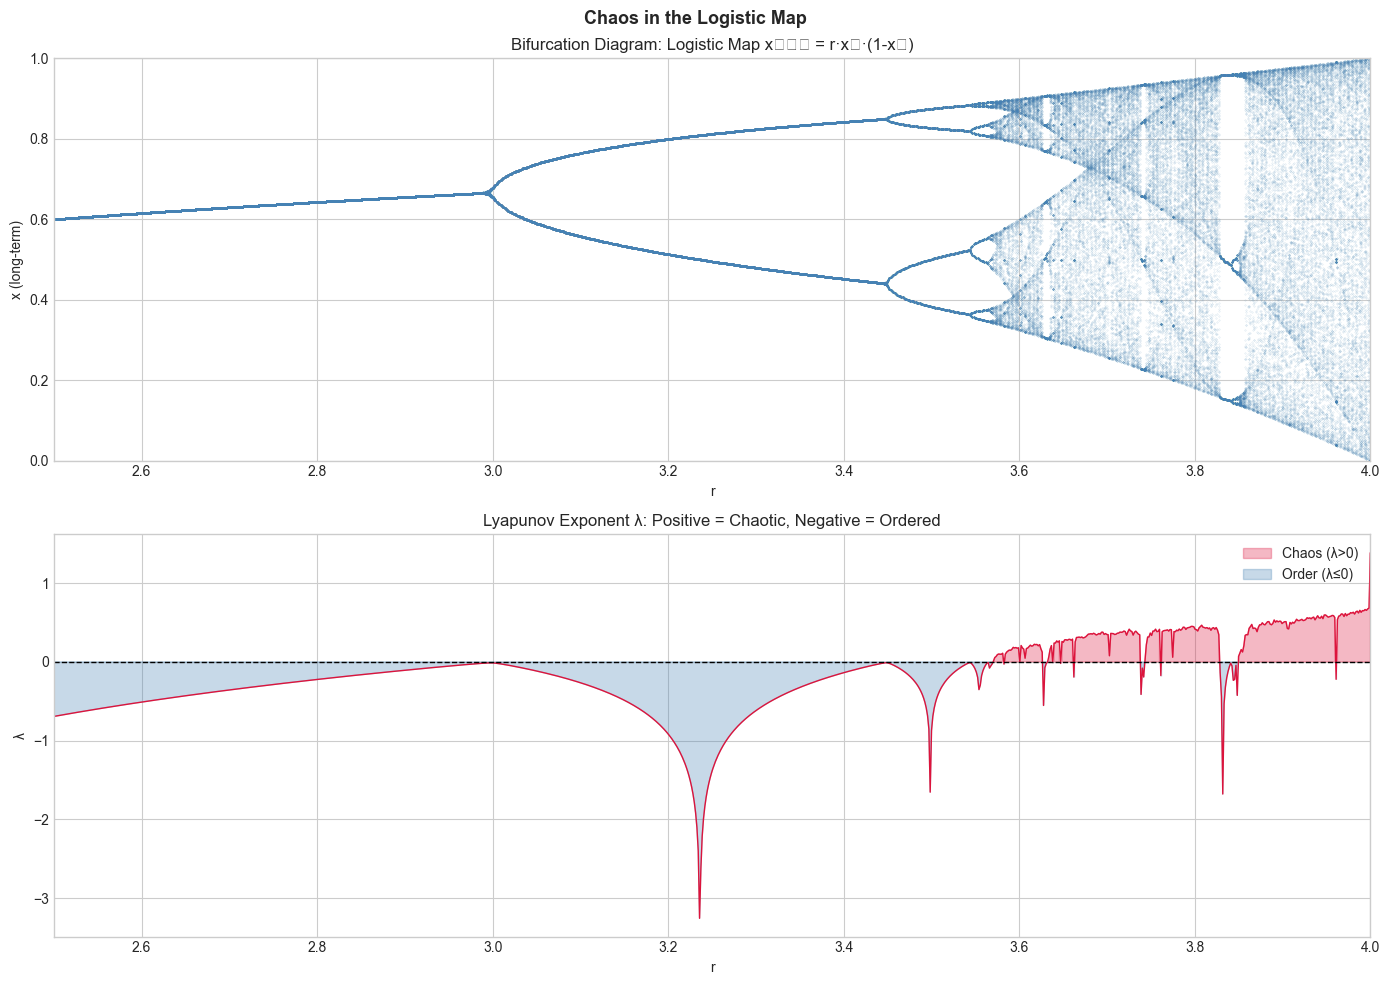

In [1]:
# --- Visualization: Bifurcation diagram + Lyapunov exponent ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def logistic(x, r): return r * x * (1 - x)

# Bifurcation diagram
r_vals = np.linspace(2.5, 4.0, 1000)
n_transient, n_plot = 300, 200
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

bif_r, bif_x = [], []
for r in r_vals:
    x = 0.5
    for _ in range(n_transient):
        x = logistic(x, r)
    for _ in range(n_plot):
        x = logistic(x, r)
        bif_r.append(r)
        bif_x.append(x)

axes[0].scatter(bif_r, bif_x, s=0.05, color='steelblue', alpha=0.3)
axes[0].set_title('Bifurcation Diagram: Logistic Map xₙ₊₁ = r·xₙ·(1-xₙ)')
axes[0].set_xlabel('r'); axes[0].set_ylabel('x (long-term)')
axes[0].set_xlim(2.5, 4.0); axes[0].set_ylim(0, 1)

# Lyapunov exponent
lyap = []
for r in r_vals:
    x = 0.5
    lsum = 0
    for i in range(500):
        x = logistic(x, r)
        deriv = abs(r * (1 - 2*x))
        if deriv > 0:
            lsum += np.log(deriv)
    lyap.append(lsum / 500)

axes[1].plot(r_vals, lyap, color='crimson', linewidth=1)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].fill_between(r_vals, lyap, 0, where=np.array(lyap) > 0, alpha=0.3, color='crimson', label='Chaos (λ>0)')
axes[1].fill_between(r_vals, lyap, 0, where=np.array(lyap) <= 0, alpha=0.3, color='steelblue', label='Order (λ≤0)')
axes[1].set_title('Lyapunov Exponent λ: Positive = Chaotic, Negative = Ordered')
axes[1].set_xlabel('r'); axes[1].set_ylabel('λ')
axes[1].set_xlim(2.5, 4.0); axes[1].legend()

plt.suptitle('Chaos in the Logistic Map', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 5. Python Implementation

Prediction horizons for logistic map (r=3.9):
Threshold divergence: 0.1
  Initial separation 1e-02: horizon = 10 steps
  Initial separation 1e-04: horizon = 26 steps
  Initial separation 1e-06: horizon = 45 steps
  Initial separation 1e-08: horizon = 62 steps
  Initial separation 1e-10: horizon = 200 steps


C:\Users\user\AppData\Local\Temp\ipykernel_15392\3480896571.py:52: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


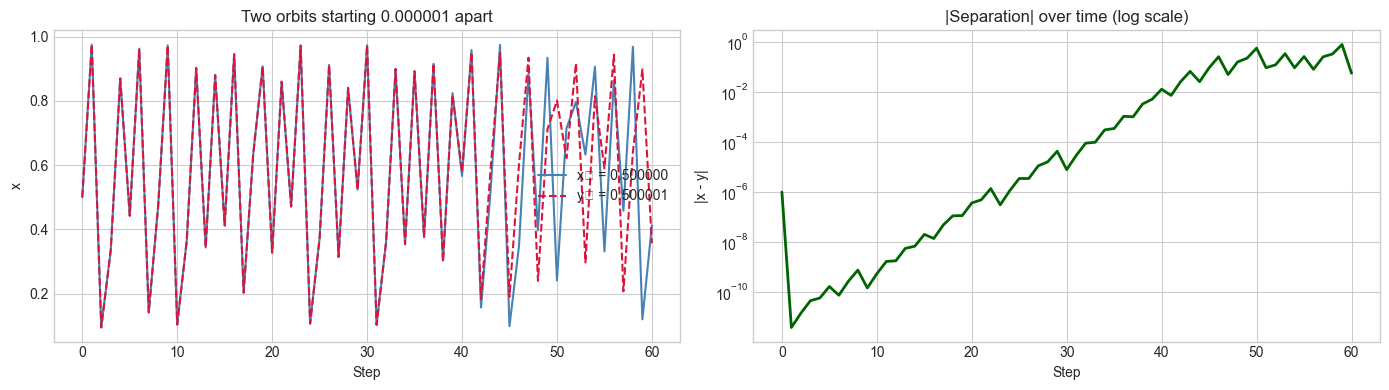

In [2]:
# --- Implementation: Sensitive dependence and prediction horizon ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def logistic(x, r=3.9): return r * x * (1 - x)

def prediction_horizon(f, x0, delta, threshold=0.1, max_steps=200):
    """Find when two nearby orbits diverge beyond threshold."""
    x = x0
    y = x0 + delta
    for n in range(max_steps):
        x = f(x)
        y = f(y)
        if abs(x - y) > threshold:
            return n
    return max_steps

# Sensitivity demonstration
x0 = 0.5000000
deltas = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]
print("Prediction horizons for logistic map (r=3.9):")
print(f"Threshold divergence: 0.1")
for d in deltas:
    h = prediction_horizon(logistic, x0, d)
    print(f"  Initial separation {d:.0e}: horizon = {h} steps")

# Two orbits diverging
n_steps = 60
x = 0.500000
y = 0.500001
orbit_x = [x]
orbit_y = [y]
for _ in range(n_steps):
    x = logistic(x)
    y = logistic(y)
    orbit_x.append(x)
    orbit_y.append(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
t = np.arange(n_steps + 1)
axes[0].plot(t, orbit_x, color='steelblue', linewidth=1.5, label='x₀ = 0.500000')
axes[0].plot(t, orbit_y, color='crimson', linewidth=1.5, linestyle='--', label='y₀ = 0.500001')
axes[0].set_title('Two orbits starting 0.000001 apart'); axes[0].legend()
axes[0].set_xlabel('Step'); axes[0].set_ylabel('x')

diffs = np.abs(np.array(orbit_x) - np.array(orbit_y))
axes[1].semilogy(t, diffs + 1e-16, color='darkgreen', linewidth=2)
axes[1].set_title('|Separation| over time (log scale)'); axes[1].set_xlabel('Step')
axes[1].set_ylabel('|x - y|')

plt.tight_layout()
plt.show()

---

## 6. Experiments

**Experiment 1:** Increase the initial separation from 1e-10 to 1e-2 in the prediction horizon function. Verify that the horizon drops roughly logarithmically with delta (horizon ≈ -log(delta)/λ).

**Experiment 2:** Compare the logistic map at r=3.5 (period-4 orbit) vs r=3.9 (chaos). Plot |orbit_x - orbit_y| for both. What is the Lyapunov exponent of each?

---

## 7. Exercises

**Easy 1.** Run the logistic map at r=3.0 for 200 steps. Does it settle into a fixed point, period-2 cycle, or chaos?

**Easy 2.** Compute the Lyapunov exponent of the logistic map at r=2.0, r=3.2, r=4.0. Classify each as ordered or chaotic.

**Medium 1.** Implement the tent map: f(x) = 2x if x < 0.5, else 2(1-x). Compute its Lyapunov exponent analytically (log 2) and verify numerically.

**Medium 2.** The Feigenbaum constant δ ≈ 4.669 governs period doubling: the first bifurcation is at r₁≈3, then r₂≈3.449, r₃≈3.544, etc. Verify: (r₂-r₁)/(r₃-r₂) ≈ δ.

**Hard.** Implement the Hénon map (2D chaos): xₙ₊₁ = 1 - a·xₙ² + yₙ, yₙ₊₁ = b·xₙ. With a=1.4, b=0.3, plot 100,000 iterations. Compute the Lyapunov exponents of the 2D system using the Jacobian.

---

## 9. Chapter Summary & Connections

- Chaos: deterministic, sensitive to initial conditions, aperiodic, dense periodic orbits
- Lyapunov exponent λ: positive = chaos, negative = order
- Bifurcation diagram shows how attractors change with parameter r
- Prediction horizon ≈ -log(measurement error) / λ — precision determines predictability

**Forward connections:**
- Chaos appears in the double pendulum, weather models, and fluid turbulence
- Lyapunov exponents are connected to information theory — they measure information loss rate
- ch090 (Chaos Simulator) builds a full interactive chaotic system